# Phase 3b: Layer 3 LSTM, Building Training Sequences

**Project:** A Perception-Aware Framework for Evaluating Counterfactual Passing Options in Professional Football

**Author:** Raeesa Lorgat (2686242)

**Purpose of this notebook:** RQ3 needs an LSTM that predicts where a teammate outside the passer's vision cone is at the moment of a pass. Training it needs many examples of the form "where this player was over the last few moments, and where they are now", which requires following the same player through time.

StatsBomb gives two partial sources. Events carry player identity but only record a player's position when they touch the ball. 360 freeze frames record everyone the camera sees, on or off the ball, but with no identity. The ground truth already saved in `setup_euro2024.ipynb` (`../data/lstm_eval_all3/`) holds positions of invisible teammates at each pass, but no sequences and no identity.

The approach tested here is to link consecutive freeze frames into anonymous tracks: match each player in one frame to the most likely player in the next frame, using the Hungarian assignment method, and chain those matches. The LSTM does not need to know who a player is, only that it is the same player across frames. This matches the proposal's description of sequences extracted from 360 freeze frames.

Before building anything, this notebook checks whether that linking is reliable enough to use. If it is not, the fallback is to build sequences from event touches instead.

In [18]:
import warnings
warnings.filterwarnings('ignore')

import time
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

from statsbombpy import sb
import statsbombpy.public as sbpublic

sbpublic.OPEN_DATA_PATHS = {
    k: v.replace(
        "https://raw.githubusercontent.com/statsbomb/open-data/master",
        "https://cdn.jsdelivr.net/gh/statsbomb/open-data@master",
    )
    for k, v in sbpublic.OPEN_DATA_PATHS.items()
}

pd.set_option('display.max_columns', None)

In [19]:
CACHE_DIR = Path("../data/statsbomb_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def cached_events(match_id, retries=5, backoff=5):
    cache_file = CACHE_DIR / f"events_{match_id}.pkl"
    if cache_file.exists():
        return pd.read_pickle(cache_file)
    for attempt in range(retries):
        try:
            events = sb.events(match_id=match_id)
            events.to_pickle(cache_file)
            return events
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"events fetch failed ({e}), retrying in {wait}s...")
            time.sleep(wait)

def cached_frames(match_id, retries=5, backoff=5):
    cache_file = CACHE_DIR / f"frames_{match_id}.pkl"
    if cache_file.exists():
        return pd.read_pickle(cache_file)
    for attempt in range(retries):
        try:
            frames = sb.frames(match_id=match_id, fmt='dataframe')
            frames.to_pickle(cache_file)
            return frames
        except Exception as e:
            if attempt == retries - 1:
                raise
            wait = backoff * (attempt + 1)
            print(f"frames fetch failed ({e}), retrying in {wait}s...")
            time.sleep(wait)

Match list

The diagnostics run on a sample of 10 matches to keep them fast. The match ids come from the ground-truth files saved in `setup_euro2024.ipynb`, so they are the same 166 matches used everywhere else.

In [20]:
lstm_eval_files = sorted(glob.glob('../data/lstm_eval_all3/lstm_eval_match_*.pkl'))
all_match_ids = [f.split('lstm_eval_match_')[-1].replace('.pkl', '') for f in lstm_eval_files]
print(f"{len(all_match_ids)} matches with ground-truth files")

rng = np.random.default_rng(42)
sample_ids = list(rng.choice(all_match_ids, size=10, replace=False))
print("sample:", sample_ids)

# a quick look at the ground truth itself
gt_sample = pd.read_pickle(lstm_eval_files[0])
print(gt_sample.columns.tolist())
print(gt_sample.head(3))

166 matches with ground-truth files
sample: ['3942382', '3930165', '3788755', '3869220', '3857273', '3857272', '3869685', '3788756', '3788774', '3930182']
['match_id', 'original_event_id', 'teammate_location', 'passer_location', 'time_seconds']
  match_id                     original_event_id  \
0  3788741  84b9b798-0fbe-45bc-a4bf-3621959f29ce   
1  3788741  84b9b798-0fbe-45bc-a4bf-3621959f29ce   
2  3788741  bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6   

                         teammate_location passer_location  time_seconds  
0   [26.93356588491408, 52.10449632327261]    [36.2, 30.4]  00:00:04.288  
1   [39.14718295089656, 9.114432771958619]    [36.2, 30.4]  00:00:04.288  
2  [5.548955714553429, 30.921108395233077]     [3.3, 12.7]  00:00:16.420  


A time-ordered frame table

Each freeze frame belongs to one event. Joining frames to events gives each frame a period, a precise timestamp, and the acting team and player. StatsBomb's `timestamp` resets at the start of each period and has millisecond precision, which is finer than the `minute * 60 + second` used in the proxy notebook.

The `teammate` flag in a freeze frame is relative to the acting team, so it flips meaning whenever possession changes. `row_team_id` converts it into an absolute team id for every row.

In [21]:
def build_frame_table(mid):
    frames = cached_frames(str(mid))
    events = cached_events(str(mid))

    team_ids = events['team_id'].dropna().unique()
    assert len(team_ids) == 2, f"expected 2 teams, found {team_ids}"
    other_team = {team_ids[0]: team_ids[1], team_ids[1]: team_ids[0]}

    ev = events[['id', 'period', 'timestamp', 'team_id', 'player_id', 'type']].copy()
    ev['t'] = pd.to_timedelta(ev['timestamp'].astype(str)).dt.total_seconds()
    ev = ev.rename(columns={
        'id': 'event_id', 'team_id': 'acting_team_id',
        'player_id': 'actor_player_id', 'type': 'event_type',
    })

    f = frames.merge(ev, left_on='id', right_on='event_id', how='inner')
    f['row_team_id'] = np.where(f['teammate'], f['acting_team_id'], f['acting_team_id'].map(other_team))
    f['x'] = f['location'].str[0]
    f['y'] = f['location'].str[1]
    return f.sort_values(['period', 't', 'event_id']).reset_index(drop=True)


frame_tables = {mid: build_frame_table(mid) for mid in sample_ids}

f0 = frame_tables[sample_ids[0]]
print(f"match {sample_ids[0]}: {f0['event_id'].nunique()} frames, {len(f0)} player rows")
print(f0['event_type'].value_counts().head(10))
print(f0[['period', 't', 'event_type', 'acting_team_id', 'teammate', 'actor', 'keeper', 'row_team_id', 'x', 'y']].head(10))

match 3942382: 2839 frames, 48493 player rows
event_type
Ball Receipt*    13991
Pass             13211
Carry            12435
Pressure          3329
Ball Recovery     1192
Duel               852
Block              593
Clearance          518
Shot               401
Dispossessed       328
Name: count, dtype: int64
   period      t event_type  acting_team_id  teammate  actor  keeper  \
0       1  0.492       Pass             941      True  False   False   
1       1  0.492       Pass             941      True  False   False   
2       1  0.492       Pass             941      True  False   False   
3       1  0.492       Pass             941      True  False   False   
4       1  0.492       Pass             941      True  False   False   
5       1  0.492       Pass             941      True  False   False   
6       1  0.492       Pass             941      True  False   False   
7       1  0.492       Pass             941     False  False   False   
8       1  0.492       Pass            

What the frame table shows

The join works. In match 3942382 there are 2839 freeze frames holding 48493 player rows, about 17 players per frame across both teams. Frames exist for most event types, not only passes: ball receipts, carries, pressures, recoveries and duels all have one. That is what puts frames close together in time, and so is what makes linking possible at all.

The event type counts above count player rows, not frames, which is why they are much larger than the number of events of each type.

Do coordinates flip when possession changes?

If each frame is drawn from the acting team's point of view, a team's own goalkeeper will appear at one end of the pitch when that team is acting and at the other end when the opponent is acting. If coordinates are fixed for the whole period, the keeper stays at the same end regardless of who is acting.

This decides whether frames from different acting teams can be linked directly or need converting to a common frame first. Until it is settled, the linking in Step 4 only joins consecutive frames where the same team is acting, which is safe either way.

In [22]:
for mid in sample_ids[:3]:
    f = frame_tables[mid]
    keepers = f[f['keeper']]
    print(f"match {mid}")
    print(keepers.groupby(['period', 'row_team_id', 'acting_team_id'])['x'].agg(['mean', 'count']).round(1))
    print()

match 3942382
                                    mean  count
period row_team_id acting_team_id              
1      909         909               8.1    160
                   941             111.7    130
       941         909             110.2     88
                   941              12.0     88
2      909         909               8.0    107
                   941             116.1     93
       941         909             113.7     69
                   941              13.3     91

match 3930165
                                    mean  count
period row_team_id acting_team_id              
1      771         771              10.9    226
                   915             113.2    122
       915         771             106.5    141
                   915              10.6    179
2      771         771              11.0    178
                   915             109.3    202
       915         771             110.8    166
                   915              12.3    198

match 3788

What the orientation check shows

Coordinates flip with possession. In all three matches, each team's goalkeeper sits near x = 10 when that team is acting and near x = 110 when the opponent is acting. So every freeze frame is drawn from the acting team's point of view, with the acting team always attacking toward x = 120. The pattern is the same in both periods, so there is no separate half-time switch to handle.

This has two consequences for linking. First, frames from different acting teams cannot be linked directly, because a player standing still would appear to jump across the pitch when possession changes. The opponent's frames have to be converted into the same view first, by rotating them 180 degrees: x becomes 120 minus x, and y becomes 80 minus y. Second, without that conversion every possession change would break the tracks, and the timing check below shows possession changes make up 28 percent of consecutive frame pairs.

The keeper check only proves the x flip. That y flips as well is the standard StatsBomb convention, and it is tested directly at the end of this notebook.

It also confirms the Layer 2 offside logic is safe. Because the acting team always attacks toward x = 120, the attacking direction derived from the opponent keeper always lands on the same branch of `is_offside`, which is the correct one.

How far apart are consecutive frames, and how many players does each show?

Linking only works if frames are close together in time. Players sprint at up to about 8 to 9 metres per second, so over half a second a player moves a few metres at most, but over 5 seconds they can cross a large part of the pitch.

This step measures the time gap between consecutive frames within each period, how often consecutive frames share the same acting team, and how many players of the acting team each frame shows.

32751 frames across 10 matches
count    32725.00
mean         1.95
std          6.89
min          0.00
25%          0.00
50%          0.73
75%          1.57
max        223.84
Name: gap, dtype: float64
share of gaps <= 0.5s: 44.1%
share of gaps <= 1s: 58.3%
share of gaps <= 2s: 82.3%
share of gaps <= 3s: 89.8%
share of gaps <= 5s: 94.7%
share of consecutive frames with the same acting team: 72.0%

acting-team players per frame (actor included):
count    32751.00
mean         7.51
std          1.86
min          1.00
25%          6.00
50%          8.00
75%          9.00
max         11.00
Name: n_acting_team_rows, dtype: float64


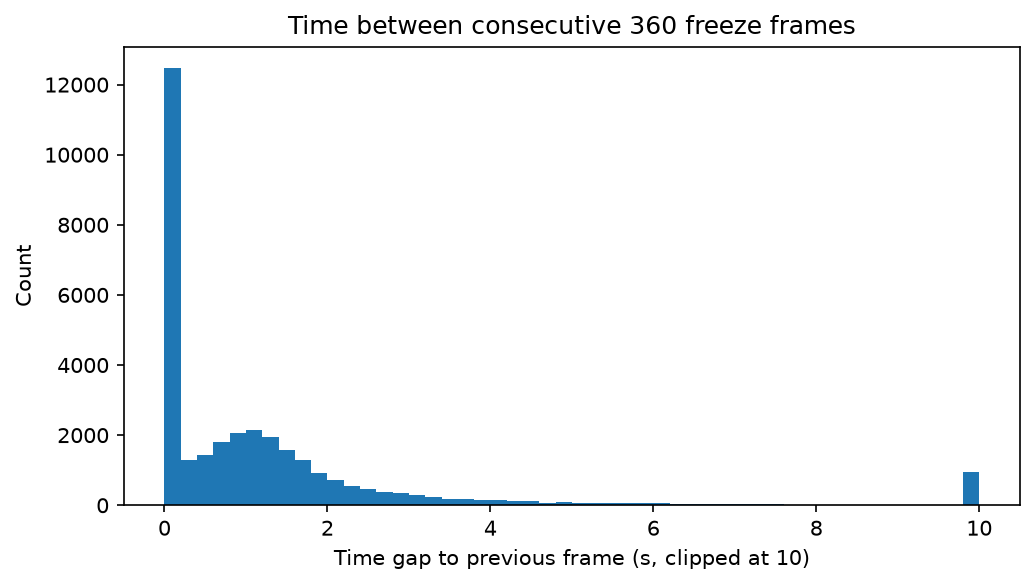

In [23]:
frame_level = []
for mid in sample_ids:
    f = frame_tables[mid]
    fr = f.groupby('event_id').agg(
        period=('period', 'first'),
        t=('t', 'first'),
        acting_team_id=('acting_team_id', 'first'),
        actor_player_id=('actor_player_id', 'first'),
        n_acting_team_rows=('teammate', 'sum'),
    ).sort_values(['period', 't'])
    fr['gap'] = fr.groupby('period')['t'].diff()
    fr['same_team_as_prev'] = fr['acting_team_id'].eq(fr.groupby('period')['acting_team_id'].shift())
    fr['match_id'] = mid
    frame_level.append(fr.reset_index())

frame_summary = pd.concat(frame_level, ignore_index=True)

gaps = frame_summary['gap'].dropna()
print(f"{len(frame_summary)} frames across {len(sample_ids)} matches")
print(gaps.describe().round(2))
for g in [0.5, 1, 2, 3, 5]:
    print(f"share of gaps <= {g}s: {(gaps <= g).mean():.1%}")
print(f"share of consecutive frames with the same acting team: {frame_summary['same_team_as_prev'].mean():.1%}")
print()
print("acting-team players per frame (actor included):")
print(frame_summary['n_acting_team_rows'].describe().round(2))

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
ax.hist(gaps.clip(upper=10), bins=50)
ax.set_xlabel('Time gap to previous frame (s, clipped at 10)')
ax.set_ylabel('Count')
ax.set_title('Time between consecutive 360 freeze frames')
plt.tight_layout()
plt.show()

What the timing shows

Frames are close together. The median gap between consecutive frames is 0.73 seconds, 82.3 percent of gaps are 2 seconds or less, and 94.7 percent are 5 seconds or less. The long tail, up to 224 seconds, comes from stoppages such as injuries, substitutions and the ball going out of play. A track should simply end at a gap that long.

A quarter of gaps are exactly zero. These are most likely separate events recorded at the same instant, for example a pressure and the carry it is applied to, which show the same positions.

72.0 percent of consecutive frames have the same acting team, so the other 28 percent are possession changes. That is why converting coordinates between the two teams' views matters.

Each frame shows on average 7.5 of the acting team's 11 players (median 8). So about three teammates are off camera in a typical frame, and a player's track will have gaps where they leave and re-enter the broadcast view. The linking has to allow players to appear and disappear, rather than forcing every player to be matched to someone.

Can frames be linked reliably? A check where the answer is known

When the same player acts in two consecutive events, for example receiving the ball and then carrying it, the actor row in both frames is the same person. So in that case we know what the correct link is.

For every such pair (same period, same acting team, gap of at most 5 seconds), the acting team's players in the first frame are matched to the acting team's players in the second frame using the Hungarian method, which finds the pairing with the smallest total distance. The link is correct if the actor in the first frame is paired with the actor in the second frame.

This is a best-case check. The ball carrier is usually the easiest player to follow, and off-ball players will be harder. If linking fails here it will fail everywhere, and the event-touch fallback is the way to go. If it passes, the next step tests off-ball players more directly.

In [24]:
link_results = []

for mid in sample_ids:
    f = frame_tables[mid]
    frames_by_id = {eid: g for eid, g in f.groupby('event_id')}
    order = frame_summary[frame_summary['match_id'] == mid].reset_index(drop=True)

    for i in range(1, len(order)):
        prev, cur = order.iloc[i - 1], order.iloc[i]
        if prev['period'] != cur['period'] or prev['acting_team_id'] != cur['acting_team_id']:
            continue
        gap = cur['t'] - prev['t']
        if gap > 5:
            continue
        if pd.isna(prev['actor_player_id']) or prev['actor_player_id'] != cur['actor_player_id']:
            continue

        a = frames_by_id[prev['event_id']]
        b = frames_by_id[cur['event_id']]
        team_a = a[a['teammate']]
        team_b = b[b['teammate']]
        if not team_a['actor'].any() or not team_b['actor'].any():
            continue

        cost = np.hypot(
            team_a['x'].values[:, None] - team_b['x'].values[None, :],
            team_a['y'].values[:, None] - team_b['y'].values[None, :],
        )
        rows, cols = linear_sum_assignment(cost)
        assigned = dict(zip(rows, cols))

        actor_a = int(np.flatnonzero(team_a['actor'].values)[0])
        actor_b = int(np.flatnonzero(team_b['actor'].values)[0])

        link_results.append({
            'match_id': mid,
            'gap': gap,
            'correct': assigned.get(actor_a) == actor_b,
            'n_players_a': len(team_a),
            'n_players_b': len(team_b),
            'actor_moved': cost[actor_a, actor_b],
        })

link = pd.DataFrame(link_results)
link['gap_bucket'] = pd.cut(link['gap'], [0, 0.5, 1, 2, 3, 5], include_lowest=True)

print(f"{len(link)} same-actor frame pairs tested")
print(f"overall linking accuracy: {link['correct'].mean():.1%}")
print()
print(link.groupby('gap_bucket')['correct'].agg(['mean', 'size']).round(3))
print()
print("how far the actor moved between the two frames:")
print(link['actor_moved'].describe().round(2))
print()
print("accuracy when both frames show the same number of acting-team players:",
      f"{link.loc[link['n_players_a'] == link['n_players_b'], 'correct'].mean():.1%}")
print("accuracy when the number of players differs:",
      f"{link.loc[link['n_players_a'] != link['n_players_b'], 'correct'].mean():.1%}")

14664 same-actor frame pairs tested
overall linking accuracy: 96.2%

                mean  size
gap_bucket                
(-0.001, 0.5]  0.990  9770
(0.5, 1.0]     0.937  1245
(1.0, 2.0]     0.944  2051
(2.0, 3.0]     0.871   906
(3.0, 5.0]     0.782   692

how far the actor moved between the two frames:
count    14664.00
mean         2.77
std          9.60
min          0.00
25%          0.00
50%          0.00
75%          1.94
max        131.71
Name: actor_moved, dtype: float64

accuracy when both frames show the same number of acting-team players: 98.0%
accuracy when the number of players differs: 87.6%


What the linking check shows

Linking passes the best-case check. Across 14664 same-actor frame pairs, the actor was linked correctly 96.2 percent of the time. Accuracy depends strongly on the time gap: 99.0 percent at half a second or less, about 94 percent between half a second and 2 seconds, 87.1 percent at 2 to 3 seconds, and 78.2 percent at 3 to 5 seconds.

Two caveats stop this from being the whole answer. First, the 99.0 percent bucket is flattered by near-duplicate frames. The median distance the actor moved between the two frames is 0.00, so many pairs are two events at the same moment showing the same positions, where linking is trivial. The 1 to 2 second bucket, at 94.4 percent, is a more honest figure. Second, this only tests the ball carrier, who is the easiest player to follow.

The clearest failure pattern is a change in the number of players on screen. When both frames show the same number of acting-team players, accuracy is 98.0 percent. When a player enters or leaves the camera view, it drops to 87.6 percent. The Hungarian method pairs everyone it can, so when one player disappears it forces someone else into their slot. The fix is to reject any pairing longer than a player could physically run in the time gap, so an unmatched player ends their track instead of taking over someone else's.

Decision so far: build sequences from linked freeze frames, with three rules taken from these results. Rotate the other team's frames into a common view so possession changes can be linked, end a track at any gap over 2 seconds, and reject pairings longer than a plausible running distance. Before training anything, the linking still has to be tested on off-ball players, since those are the players the LSTM will predict.

Following off-ball players: a chain test

The LSTM predicts teammates who do not have the ball, so linking needs to hold for off-ball players across several frames, not just for the ball carrier between two frames.

There is one situation where the right answer is still known. When a player acts (for example passes the ball), then spends some time off the ball, then acts again, their actor row is known at both ends. Starting from the first actor row, the chain of frame-to-frame links is followed through every frame in between. The chain is **correct** if it ends on the same player's actor row, **wrong** if it ends on someone else, and **broken** if a link is missing along the way: a gap over 2 seconds, the player leaving the camera view, or a pairing longer than they could have run.

This applies the three rules from the checks above. Frames from the other team's possession are rotated into the tracked team's own view, no link is made across a gap over 2 seconds, and any pairing longer than a running speed of 10 yards per second plus a 2 yard margin is rejected. Coordinates are in StatsBomb yards throughout.

In [25]:
PITCH_X, PITCH_Y = 120.0, 80.0
MAX_GAP = 2.0            # seconds, longest gap a link is allowed to cross
MAX_SPEED = 10.0         # yards per second, roughly top sprint speed
MARGIN = 2.0             # yards, allowance for freeze-frame position noise
MAX_CHAIN_SECONDS = 60   # only test chains up to a minute long


def team_view(f, team_id, rotate_y=True):
    """All rows of `team_id` in every frame, expressed in `team_id`'s own attacking view."""
    rows = f[f['row_team_id'] == team_id].copy()
    flip = rows['acting_team_id'] != team_id
    rows.loc[flip, 'x'] = PITCH_X - rows.loc[flip, 'x']
    if rotate_y:
        rows.loc[flip, 'y'] = PITCH_Y - rows.loc[flip, 'y']
    return rows


def build_team_sequence(mid, team_id, rotate_y=True):
    """
    One entry per frame of the match, in time order, holding this team's
    visible player positions and, when this team is acting, which row is the actor.
    Frames where the team has nobody on camera keep an empty position array.
    """
    rows = team_view(frame_tables[mid], team_id, rotate_y)
    rows_by_frame = {eid: g for eid, g in rows.groupby('event_id')}
    order = frame_summary[frame_summary['match_id'] == mid].sort_values(['period', 't']).reset_index(drop=True)

    seq = []
    for _, fr in order.iterrows():
        team_acting = fr['acting_team_id'] == team_id
        g = rows_by_frame.get(fr['event_id'])
        if g is None:
            xy, actor_idx = np.empty((0, 2)), None
        else:
            xy = g[['x', 'y']].to_numpy()
            actor_flags = g['actor'].to_numpy()
            actor_idx = int(np.flatnonzero(actor_flags)[0]) if (team_acting and actor_flags.any()) else None
        seq.append({
            'period': fr['period'],
            't': fr['t'],
            'acting_team_id': fr['acting_team_id'],
            'actor_player_id': fr['actor_player_id'] if team_acting else None,
            'xy': xy,
            'actor_idx': actor_idx,
        })
    return seq


def link_pair(xy_a, xy_b, gap):
    """Hungarian pairing between two frames, dropping any pair further apart than a player could run."""
    if len(xy_a) == 0 or len(xy_b) == 0:
        return {}
    cost = np.hypot(xy_a[:, 0][:, None] - xy_b[:, 0][None, :],
                    xy_a[:, 1][:, None] - xy_b[:, 1][None, :])
    r, c = linear_sum_assignment(cost)
    keep = cost[r, c] <= MAX_SPEED * gap + MARGIN
    return dict(zip(r[keep].tolist(), c[keep].tolist()))


def consecutive_links(seq):
    """links[k] maps row positions in frame k to frame k+1, or is None if no link is allowed."""
    links = []
    for k in range(len(seq) - 1):
        a, b = seq[k], seq[k + 1]
        gap = b['t'] - a['t']
        if a['period'] != b['period'] or gap > MAX_GAP:
            links.append(None)
        else:
            links.append(link_pair(a['xy'], b['xy'], gap))
    return links


def chain_test_for_team(seq, links):
    results = []
    n = len(seq)
    for i in range(n):
        p = seq[i]['actor_player_id']
        if seq[i]['actor_idx'] is None or p is None or pd.isna(p):
            continue

        # the next frame where the same player acts again
        j = None
        for k in range(i + 1, n):
            if seq[k]['period'] != seq[i]['period'] or seq[k]['t'] - seq[i]['t'] > MAX_CHAIN_SECONDS:
                break
            if seq[k]['actor_player_id'] == p and seq[k]['actor_idx'] is not None:
                j = k
                break
        if j is None or j == i + 1:   # need at least one frame off the ball in between
            continue

        crosses_possession = any(seq[k]['acting_team_id'] != seq[i]['acting_team_id'] for k in range(i + 1, j))

        pos, status = seq[i]['actor_idx'], 'correct'
        for k in range(i, j):
            if links[k] is None or pos not in links[k]:
                status = 'broken'
                break
            pos = links[k][pos]
        if status == 'correct' and pos != seq[j]['actor_idx']:
            status = 'wrong'

        results.append({
            'status': status,
            'steps': j - i,
            'elapsed': seq[j]['t'] - seq[i]['t'],
            'crosses_possession': crosses_possession,
        })
    return results


def run_chain_test(rotate_y=True):
    rows = []
    for mid in sample_ids:
        for team_id in frame_tables[mid]['acting_team_id'].unique():
            seq = build_team_sequence(mid, team_id, rotate_y)
            links = consecutive_links(seq)
            for r in chain_test_for_team(seq, links):
                r['match_id'], r['team_id'] = mid, team_id
                rows.append(r)
    return pd.DataFrame(rows)

In [26]:
chains = run_chain_test(rotate_y=True)
chains['elapsed_bucket'] = pd.cut(chains['elapsed'], [0, 2, 5, 10, 20, 60], include_lowest=True)

print(f"{len(chains)} off-ball chains tested")
print(chains['status'].value_counts(normalize=True).round(3))
print()

completed = chains[chains['status'] != 'broken']
print(f"accuracy among chains that stayed linked: {(completed['status'] == 'correct').mean():.1%}")
print()

print("by time spent off the ball (seconds):")
print(chains.groupby('elapsed_bucket')['status'].value_counts(normalize=True).unstack().round(3))
print(chains.groupby('elapsed_bucket').size().rename('n'))
print()

print("by whether possession changed during the chain:")
print(chains.groupby('crosses_possession')['status'].value_counts(normalize=True).unstack().round(3))

10480 off-ball chains tested
status
broken     0.846
correct    0.142
wrong      0.012
Name: proportion, dtype: float64

accuracy among chains that stayed linked: 92.3%

by time spent off the ball (seconds):
status          broken  correct  wrong
elapsed_bucket                        
(-0.001, 2.0]    0.618    0.361  0.021
(2.0, 5.0]       0.601    0.362  0.037
(5.0, 10.0]      0.930    0.060  0.010
(10.0, 20.0]     0.994    0.006  0.000
(20.0, 60.0]     1.000    0.000  0.000
elapsed_bucket
(-0.001, 2.0]    2144
(2.0, 5.0]       1730
(5.0, 10.0]      1378
(10.0, 20.0]     1573
(20.0, 60.0]     3655
Name: n, dtype: int64

by whether possession changed during the chain:
status              broken  correct  wrong
crosses_possession                        
False                0.725    0.262  0.013
True                 0.870    0.118  0.012


What the chain test shows

When a chain stays linked, it is almost always right. Of the chains that were never lost, 92.3 percent ended on the correct player. For players off the ball for 2 seconds or less the figure is about 94 percent (36.1 percent correct against 2.1 percent wrong), and for 2 to 5 seconds about 91 percent. So the tracks this method produces can be trusted.

The problem is how long they last. 84.6 percent of chains broke before reaching the end. Even players off the ball for 2 seconds or less lost their chain 61.8 percent of the time, and beyond 5 seconds almost every chain broke: 93.0 percent at 5 to 10 seconds and over 99 percent beyond 10. Part of this is by design, since no link is made across a gap over 2 seconds. The rest comes from players dropping out of the camera view (about three teammates are off camera in a typical frame) or moving further between frames than the distance limit allows.

Chains that cross a possession change break more often (87.0 against 72.5 percent), but are nearly as accurate when they survive (about 91 against 95 percent), so the rotation between the two teams' views is working.

This matters for the LSTM. The proposal uses a window of 10 frames, with 5 and 15 as sensitivity checks. With a median gap of 0.73 seconds, 10 frames is roughly 7 seconds of history, and very few tracks currently last that long. The next check looks at why chains break and whether they can be made to last longer without losing accuracy.

Does the y coordinate flip as well?

The keeper check only showed that x flips when possession changes. The standard StatsBomb convention is a full 180 degree rotation, which flips y too. This reruns the chain test with only x flipped. If the full rotation is right, chains that cross a possession change should do clearly worse when y is left alone, while chains within one possession should be unaffected.

In [27]:
chains_x_only = run_chain_test(rotate_y=False)

for name, df in [('rotate x and y', chains), ('rotate x only', chains_x_only)]:
    cross = df[df['crosses_possession']]
    same = df[~df['crosses_possession']]
    print(name)
    print("  crossing possession:", cross['status'].value_counts(normalize=True).round(3).to_dict())
    print("  within possession:  ", same['status'].value_counts(normalize=True).round(3).to_dict())

rotate x and y
  crossing possession: {'broken': 0.87, 'correct': 0.118, 'wrong': 0.012}
  within possession:   {'broken': 0.725, 'correct': 0.262, 'wrong': 0.013}
rotate x only
  crossing possession: {'broken': 0.985, 'correct': 0.01, 'wrong': 0.005}
  within possession:   {'broken': 0.725, 'correct': 0.262, 'wrong': 0.013}


What the y-flip check shows

The full rotation is right. With both x and y flipped, 11.8 percent of chains that cross a possession change end on the correct player. With only x flipped, that falls to 1.0 percent and 98.5 percent of them break, because without the y flip every player appears mirrored across the width of the pitch, a jump the distance limit rejects. Chains within a single possession are identical in both runs, as they should be, since no rotation is applied to them.

So every freeze frame is expressed in the acting team's view, and moving between the two teams' views means a 180 degree rotation: x becomes 120 minus x, and y becomes 80 minus y.

Why do chains break, and can tracks last longer?

Two changes could make tracks last longer:

1. **A larger margin.** Freeze-frame positions are estimated from broadcast video, so the same player's position can jitter by a few yards between frames even when they barely move. A 2 yard margin may be cutting real links.
2. **Bridging missed frames.** If a player drops out of view for one or two frames and then reappears, the track can jump over the missing frames and carry on, instead of ending.

This first records why each chain broke, using the same settings as the chain test above, so its status split should match that test exactly. It then reruns the chain test over a grid of settings: a margin of 2, 4 or 6 yards, bridging of 0, 1 or 2 missed frames, and a maximum gap of 2 or 3 seconds.

A good setting keeps far more chains alive while keeping accuracy among surviving chains at around 90 percent or higher. Wrong links matter more than broken ones. A broken track only means less training data, but a wrong one teaches the LSTM a movement that never happened.

In [28]:
def chain_test_flexible(seq, margin=2.0, max_skip=0, max_gap=2.0):
    """
    Same chain test as above, with three adjustable settings:
    margin   : yards of allowance added to the running-distance limit
    max_skip : how many missed frames a link may jump over
    max_gap  : longest time gap (seconds) any single link may cross
    Also records why a chain broke.
    """
    link_cache = {}

    def get_link(k, s):
        key = (k, s)
        if key not in link_cache:
            a, b = seq[k], seq[k + s]
            gap = b['t'] - a['t']
            if a['period'] != b['period'] or gap > max_gap or len(a['xy']) == 0 or len(b['xy']) == 0:
                link_cache[key] = None
            else:
                cost = np.hypot(a['xy'][:, 0][:, None] - b['xy'][:, 0][None, :],
                                a['xy'][:, 1][:, None] - b['xy'][:, 1][None, :])
                r, c = linear_sum_assignment(cost)
                keep = cost[r, c] <= MAX_SPEED * gap + margin
                link_cache[key] = dict(zip(r[keep].tolist(), c[keep].tolist()))
        return link_cache[key]

    results = []
    n = len(seq)
    for i in range(n):
        p = seq[i]['actor_player_id']
        if seq[i]['actor_idx'] is None or p is None or pd.isna(p):
            continue

        j = None
        for k in range(i + 1, n):
            if seq[k]['period'] != seq[i]['period'] or seq[k]['t'] - seq[i]['t'] > MAX_CHAIN_SECONDS:
                break
            if seq[k]['actor_player_id'] == p and seq[k]['actor_idx'] is not None:
                j = k
                break
        if j is None or j == i + 1:
            continue

        crosses_possession = any(seq[k]['acting_team_id'] != seq[i]['acting_team_id'] for k in range(i + 1, j))

        pos, k, status, reason = seq[i]['actor_idx'], i, 'correct', None
        while k < j:
            moved = False
            for s in range(1, max_skip + 2):
                if k + s > j:
                    break
                link = get_link(k, s)
                if link is not None and pos in link:
                    pos, k, moved = link[pos], k + s, True
                    break
            if not moved:
                status = 'broken'
                nxt = seq[k + 1]
                if nxt['period'] != seq[k]['period'] or nxt['t'] - seq[k]['t'] > max_gap:
                    reason = 'time gap too long'
                elif len(nxt['xy']) == 0:
                    reason = 'team not on camera'
                else:
                    reason = 'player not linked'
                break
        if status == 'correct' and pos != seq[j]['actor_idx']:
            status = 'wrong'

        results.append({
            'status': status,
            'break_reason': reason,
            'elapsed': seq[j]['t'] - seq[i]['t'],
            'crosses_possession': crosses_possession,
        })
    return results


# build each team's sequence once and reuse it for every setting
team_seqs = {}
for mid in sample_ids:
    for team_id in frame_tables[mid]['acting_team_id'].unique():
        team_seqs[(mid, team_id)] = build_team_sequence(mid, team_id, rotate_y=True)


def run_flexible(margin, max_skip, max_gap):
    rows = []
    for (mid, team_id), seq in team_seqs.items():
        for r in chain_test_flexible(seq, margin, max_skip, max_gap):
            r['match_id'], r['team_id'] = mid, team_id
            rows.append(r)
    return pd.DataFrame(rows)


baseline = run_flexible(margin=2.0, max_skip=0, max_gap=2.0)
print("status (should match the chain test above):")
print(baseline['status'].value_counts(normalize=True).round(3))
print()
print("why broken chains broke:")
print(baseline.loc[baseline['status'] == 'broken', 'break_reason'].value_counts(normalize=True).round(3))

status (should match the chain test above):
status
broken     0.846
correct    0.142
wrong      0.012
Name: proportion, dtype: float64

why broken chains broke:
break_reason
time gap too long     0.522
player not linked     0.478
team not on camera    0.000
Name: proportion, dtype: float64


What the break reasons show

The split between the two causes is almost even. 52.2 percent of broken chains hit a gap of more than 2 seconds between frames, which is a real pause in the data (a stoppage, or a stretch with no recorded events), so it should end a track rather than be bridged. The other 47.8 percent broke because the player could not be linked into the next frame, either because they dropped out of the camera view or because their position moved further than the distance limit allows. The whole team was never off camera.

The second cause is the one worth trying to fix, and it is what the settings below test.

In [29]:
sweep = []
for max_gap in [2.0, 3.0]:
    for margin in [2.0, 4.0, 6.0]:
        for max_skip in [0, 1, 2]:
            df = run_flexible(margin, max_skip, max_gap)
            survived = df[df['status'] != 'broken']
            short = df[df['elapsed'] <= 5]
            short_survived = short[short['status'] != 'broken']
            sweep.append({
                'max_gap': max_gap,
                'margin': margin,
                'max_skip': max_skip,
                'survived': (df['status'] != 'broken').mean(),
                'accuracy_if_survived': (survived['status'] == 'correct').mean(),
                'survived_upto_5s': (short['status'] != 'broken').mean(),
                'accuracy_upto_5s': (short_survived['status'] == 'correct').mean(),
                'wrong_share': (df['status'] == 'wrong').mean(),
            })
            print(f"done: max_gap {max_gap}, margin {margin}, max_skip {max_skip}")

sweep_df = pd.DataFrame(sweep).round(3)
print()
print(sweep_df.sort_values('survived', ascending=False).to_string(index=False))

done: max_gap 2.0, margin 2.0, max_skip 0
done: max_gap 2.0, margin 2.0, max_skip 1
done: max_gap 2.0, margin 2.0, max_skip 2
done: max_gap 2.0, margin 4.0, max_skip 0
done: max_gap 2.0, margin 4.0, max_skip 1
done: max_gap 2.0, margin 4.0, max_skip 2
done: max_gap 2.0, margin 6.0, max_skip 0
done: max_gap 2.0, margin 6.0, max_skip 1
done: max_gap 2.0, margin 6.0, max_skip 2
done: max_gap 3.0, margin 2.0, max_skip 0
done: max_gap 3.0, margin 2.0, max_skip 1
done: max_gap 3.0, margin 2.0, max_skip 2
done: max_gap 3.0, margin 4.0, max_skip 0
done: max_gap 3.0, margin 4.0, max_skip 1
done: max_gap 3.0, margin 4.0, max_skip 2
done: max_gap 3.0, margin 6.0, max_skip 0
done: max_gap 3.0, margin 6.0, max_skip 1
done: max_gap 3.0, margin 6.0, max_skip 2

 max_gap  margin  max_skip  survived  accuracy_if_survived  survived_upto_5s  accuracy_upto_5s  wrong_share
     3.0     6.0         2     0.353                 0.849             0.758             0.887        0.053
     3.0     4.0         2 

What the sweep shows

Bridging one missed frame is by far the most useful change. With a 2 second maximum gap and a 2 yard margin, it raises the share of chains that survive from 15.4 to 24.0 percent, and among players off the ball for up to 5 seconds from 39.0 to 60.6 percent, while accuracy among surviving chains only drops from 92.3 to 91.5 percent. Bridging a second frame adds very little (24.9 percent survival) and costs a little more accuracy.

A larger margin helps less than expected: moving from 2 to 4 or 6 yards adds only one or two points of survival, so position jitter is not the main reason players fail to link.

Allowing gaps of up to 3 seconds raises survival further, to as much as 35.3 percent, but accuracy among surviving chains falls to between 85 and 88 percent and the share of wrong chains roughly doubles, to between 3.8 and 5.3 percent. Since a wrong link teaches the LSTM a movement that never happened, while a broken one only costs some training data, the 3 second settings are rejected.

Chosen setting: a maximum gap of 2 seconds, a 2 yard margin, and bridging of up to one missed frame. Tracks built this way are accurate about 91.5 percent of the time, but most last only a few seconds. The next step builds full tracks with this setting and measures how long they are, since that decides how long the LSTM's input window can be.

Building tracks with the chosen setting

The chain test only followed one known player at a time. This builds tracks for every player on camera. Frame by frame, each active track is matched to one player in the new frame using the Hungarian method. Any pairing further than 10 yards per second of gap plus a 2 yard margin is ruled out before the matching rather than after, so a forbidden pairing cannot push other players into the wrong slots. A track that finds no match can wait one frame (bridging one missed frame). It ends if it misses two frames in a row, if the gap to the next frame is more than 2 seconds, or at the end of a period. Any player in a new frame who is not matched to an existing track starts a new one.

Two lengths matter for the LSTM. The number of frames in a track, and the number of distinct moments in time, since frames recorded at the same instant add no new movement information. A track with n distinct moments gives n minus k training windows for an input window of k steps (k past positions plus one position to predict).

In [31]:
TRACK_MAX_GAP = 2.0
TRACK_MARGIN = 2.0
TRACK_MAX_SKIP = 1


def build_tracks(seq, max_gap=TRACK_MAX_GAP, margin=TRACK_MARGIN, max_skip=TRACK_MAX_SKIP):
    """
    Link every player in a team's frame sequence into anonymous tracks.
    Each track also records, for every point, which frame (k) and which row
    of that frame it came from, so a player at a given pass can be looked up later.
    """
    finished, active = [], []
    BIG = 1e6

    for k, fr in enumerate(seq):
        # retire tracks that can no longer be continued into this frame
        still_active = []
        for tr in active:
            gap = fr['t'] - tr['t'][-1]
            if tr['period'] != fr['period'] or gap > max_gap or k - tr['last_k'] > max_skip + 1:
                finished.append(tr)
            else:
                still_active.append(tr)
        active = still_active

        xy = fr['xy']
        matched_rows = set()
        if active and len(xy):
            last = np.array([[tr['x'][-1], tr['y'][-1]] for tr in active])
            gaps = np.array([fr['t'] - tr['t'][-1] for tr in active])
            cost = np.hypot(last[:, 0][:, None] - xy[:, 0][None, :],
                            last[:, 1][:, None] - xy[:, 1][None, :])
            limit = (MAX_SPEED * gaps + margin)[:, None]
            gated = np.where(cost <= limit, cost, BIG)
            r, c = linear_sum_assignment(gated)
            for ri, ci in zip(r, c):
                if gated[ri, ci] < BIG:
                    tr = active[ri]
                    tr['t'].append(fr['t'])
                    tr['x'].append(xy[ci, 0])
                    tr['y'].append(xy[ci, 1])
                    tr['k'].append(k)
                    tr['row'].append(ci)
                    tr['last_k'] = k
                    matched_rows.add(ci)

        for ci in range(len(xy)):
            if ci not in matched_rows:
                active.append({'period': fr['period'], 't': [fr['t']],
                               'x': [xy[ci, 0]], 'y': [xy[ci, 1]], 'last_k': k,
                               'k': [k], 'row': [ci]})

    finished.extend(active)
    return finished


track_rows = []
for (mid, team_id), seq in team_seqs.items():
    for tr in build_tracks(seq):
        t = np.array(tr['t'])
        track_rows.append({
            'match_id': mid,
            'team_id': team_id,
            'n_frames': len(t),
            'n_distinct_times': len(np.unique(t)),
            'duration': t[-1] - t[0],
        })
tracks_df = pd.DataFrame(track_rows)

print(f"{len(tracks_df)} tracks built across {len(sample_ids)} matches")
print(tracks_df[['n_frames', 'n_distinct_times', 'duration']]
      .describe(percentiles=[.25, .5, .75, .9]).round(2))
print()
for k in [5, 10, 15]:
    long_enough = tracks_df['n_distinct_times'] >= k + 1
    windows = (tracks_df['n_distinct_times'] - k).clip(lower=0).sum()
    print(f"k = {k:2d}: {long_enough.mean():.1%} of tracks long enough "
          f"({long_enough.sum()} tracks), {windows} training windows")

129995 tracks built across 10 matches
        n_frames  n_distinct_times   duration
count  129995.00         129995.00  129995.00
mean        3.78              2.77       1.71
std         3.80              2.63       2.56
min         1.00              1.00       0.00
25%         1.00              1.00       0.00
50%         2.00              2.00       0.60
75%         5.00              4.00       2.53
90%         9.00              6.00       5.11
max        38.00             26.00      25.75

k =  5: 12.9% of tracks long enough (16725 tracks), 56027 training windows
k = 10: 2.3% of tracks long enough (2927 tracks), 9617 training windows
k = 15: 0.4% of tracks long enough (505 tracks), 1459 training windows


What the tracks look like

With the chosen setting, the 10 sample matches produce 129995 tracks. Most are very short: the median track has 2 distinct moments and lasts 0.6 seconds, a quarter are a single frame, and only 10 percent reach 6 distinct moments or 5.1 seconds. The longest lasts 25.8 seconds. This is what the chain test predicted. Links are accurate, but gaps of more than 2 seconds and players moving in and out of the camera view cut tracks into short pieces.

The three window lengths from the proposal give very different amounts of training data:

- k = 5: 12.9 percent of tracks are long enough, giving 56027 training windows
- k = 10: 2.3 percent, giving 9617 windows
- k = 15: 0.4 percent, giving 1459 windows

If the other matches look like these 10, that scales to roughly 930000, 160000 and 24000 windows across all 166 matches. So even k = 10 gives enough examples to train an LSTM.

The real constraint is elsewhere. Long tracks are rare and probably unusual, belonging to players who stay on camera and move steadily, so a model trained only on them may learn from an unrepresentative group, the same kind of selection problem seen in the memory-feasibility proxy. And at the moment of a pass, the model can only be applied to an invisible teammate who has enough history behind them. The next check measures that directly.

How much history does an invisible teammate have at the moment of a pass?

This is the check that decides the window length. For every invisible teammate at a qualifying pass in the 10 sample matches (taken from `candidates_full`), it finds that player's row in the pass's freeze frame, looks up which track that row belongs to, and counts how many distinct earlier moments the track has before the pass. A teammate with at least k earlier moments can be given to an LSTM with window k. One with at least 2 can be given to the linear-extrapolation baseline, which needs two points to estimate a velocity.

In [32]:
point_lookup, team_tracks = {}, {}
for (mid, team_id), seq in team_seqs.items():
    tracks = build_tracks(seq)
    team_tracks[(mid, team_id)] = tracks
    for tid, tr in enumerate(tracks):
        for pos, (k, row) in enumerate(zip(tr['k'], tr['row'])):
            point_lookup[(mid, team_id, k, row)] = (tid, pos)

candidates_full = pd.read_pickle('../data/results/candidates_full.pkl')
inv = candidates_full[~candidates_full['visible']].copy()
inv['match_id'] = inv['match_id'].astype(str)
inv = inv[inv['match_id'].isin(sample_ids)]

coverage = []
for mid in sample_ids:
    # same ordering build_team_sequence uses, so index k lines up with team_seqs
    order = frame_summary[frame_summary['match_id'] == mid].sort_values(['period', 't']).reset_index(drop=True)
    k_of_event = dict(zip(order['event_id'], order.index))
    team_of_event = dict(zip(order['event_id'], order['acting_team_id']))

    for _, cand in inv[inv['match_id'] == mid].iterrows():
        eid = cand['original_event_id']
        if eid not in k_of_event:
            coverage.append({'found': False})
            continue
        k, team_id = k_of_event[eid], team_of_event[eid]
        xy = team_seqs[(mid, team_id)][k]['xy']
        if len(xy) == 0:
            coverage.append({'found': False})
            continue
        d = np.hypot(xy[:, 0] - cand['cand_x'], xy[:, 1] - cand['cand_y'])
        row = int(d.argmin())
        if d[row] > 0.01:
            coverage.append({'found': False})
            continue

        tid, pos = point_lookup[(mid, team_id, k, row)]
        tr = team_tracks[(mid, team_id)][tid]
        t_now = tr['t'][pos]
        earlier = np.array(tr['t'][:pos])
        coverage.append({
            'found': True,
            'n_prior': len(np.unique(earlier[earlier < t_now])),
            'history_seconds': t_now - tr['t'][0],
        })

cov = pd.DataFrame(coverage)
found = cov[cov['found']]
print(f"{len(cov)} invisible teammates at passes, {cov['found'].mean():.1%} located in a track")
print()
for k in [1, 2, 3, 5, 10, 15]:
    print(f"at least {k:2d} earlier moments: {(found['n_prior'] >= k).mean():.1%}")
print()
print(found[['n_prior', 'history_seconds']].describe(percentiles=[.25, .5, .75, .9]).round(2))

25211 invisible teammates at passes, 100.0% located in a track

at least  1 earlier moments: 61.9%
at least  2 earlier moments: 46.4%
at least  3 earlier moments: 31.2%
at least  5 earlier moments: 15.3%
at least 10 earlier moments: 2.6%
at least 15 earlier moments: 0.3%

        n_prior  history_seconds
count  25211.00         25211.00
mean       2.12             2.07
std        2.70             2.65
min        0.00             0.00
25%        0.00             0.00
50%        1.00             1.22
75%        3.00             3.15
90%        6.00             5.66
max       22.00            22.99


What the coverage check shows

Every invisible teammate at a pass was found in a track, so the lookup works. But most of them have very little history behind them:

- 38.1 percent have no earlier point at all. Their track starts at the pass itself, usually because they have only just come into the camera view.
- 46.4 percent have at least 2 earlier moments, enough for the linear-extrapolation baseline to estimate a velocity.
- 15.3 percent have at least 5, 2.6 percent at least 10, and 0.3 percent at least 15.

The median invisible teammate has 1 earlier moment and 1.22 seconds of history, and even at the 90th percentile it is only 6 moments and 5.66 seconds.

This rules out the proposal's fixed window of 10 as the main design, since a model that needs exactly 10 earlier moments could only be applied to 2.6 percent of invisible teammates. A fixed window is not something an LSTM requires, though. LSTMs are built to read sequences of different lengths, so the model can be trained on histories of any length from 1 up to a maximum, and applied to every teammate with at least one earlier moment, which is 61.9 percent of them. The proposal's values of 5, 10 and 15 then become the maximum history length the model may use, which keeps them as a sensitivity check.

Two things follow for how RQ3 is reported. First, the 38.1 percent with no history cannot be predicted by any trajectory model from this data, neither the LSTM nor the linear baseline. That is a coverage limit of StatsBomb 360, not evidence that the passer had no memory of those teammates. Second, the history available is short, a second or two for a typical teammate, so what the model can test is short-term spatial memory over a few seconds, not memory over long stretches of play. Errors should be reported by history length, and the LSTM should be compared with the baselines on exactly the same teammates.

#### Building the LSTM dataset for all 166 matches

With the linking settings fixed, this builds the actual training data. For each match:

- Tracks are built for both teams with the chosen setting (2 second maximum gap, 2 yard margin, one missed frame bridged), with each team's positions kept in its own attacking view.
- Points recorded at the same instant are collapsed into one, since they add no movement information.
- Every track point that has at least one earlier point becomes a training example. The input is the up to 15 points before it (x, y and time), and the target is the point itself. Histories are stored right-aligned, so the most recent point is always last, and unused slots are left empty. This lets the model be trained with any maximum history of 15 or less, which is how the proposal's window values of 5, 10 and 15 are tested.
- Every invisible teammate at a qualifying pass (from `candidates_full`) becomes an evaluation example, with its target set to its exact freeze-frame position at the pass, the same position used in RQ2. Teammates with no earlier point are kept, so that coverage can be reported, but they cannot be scored.

Each match is saved to its own file, so the loop can be stopped and restarted without losing work. Positions stay in StatsBomb yards here and are converted to metres when errors are reported.

In [33]:
import pickle

DATASET_DIR = Path('../data/lstm_dataset')
DATASET_DIR.mkdir(parents=True, exist_ok=True)
K_MAX = 15   # longest history kept per example; the model can be told to use less


def frame_order(f):
    """One row per frame, in time order, for a single match."""
    fr = f.groupby('event_id').agg(
        period=('period', 'first'),
        t=('t', 'first'),
        acting_team_id=('acting_team_id', 'first'),
    ).reset_index()
    return fr.sort_values(['period', 't', 'event_id']).reset_index(drop=True)


def team_sequence(f, order, team_id):
    """Like build_team_sequence, but works for any match and keeps each frame's event id."""
    rows = team_view(f, team_id, rotate_y=True)
    rows_by_frame = {eid: g for eid, g in rows.groupby('event_id')}
    seq = []
    for fr in order.itertuples(index=False):
        g = rows_by_frame.get(fr.event_id)
        xy = np.empty((0, 2)) if g is None else g[['x', 'y']].to_numpy()
        seq.append({'event_id': fr.event_id, 'period': fr.period, 't': fr.t,
                    'acting_team_id': fr.acting_team_id, 'xy': xy})
    return seq


def dedupe_track(tr):
    """Collapse points recorded at the same instant, keeping the last one."""
    t, x, y = np.asarray(tr['t']), np.asarray(tr['x']), np.asarray(tr['y'])
    keep = np.append(t[1:] != t[:-1], True)
    return t[keep], x[keep], y[keep]


def history_block(t, x, y, end):
    """
    The up to K_MAX points before index `end`, as a (K_MAX, 3) array of x, y, time.
    Right-aligned, so the most recent point is always in the last row.
    Unused rows at the top are NaN.
    """
    start = max(0, end - K_MAX)
    n = end - start
    block = np.full((K_MAX, 3), np.nan, dtype=np.float32)
    if n > 0:
        block[K_MAX - n:, 0] = x[start:end]
        block[K_MAX - n:, 1] = y[start:end]
        block[K_MAX - n:, 2] = t[start:end]
    return block, n


def process_match(mid, cands, f=None):
    """
    Training examples: every tracked point with at least one earlier point.
    Evaluation examples: every invisible teammate at a qualifying pass.
    """
    if f is None:
        f = build_frame_table(mid)
    order = frame_order(f)
    k_of_event = dict(zip(order['event_id'], order.index))

    train_hist, train_target, train_nhist, train_team = [], [], [], []
    seqs, lookups, deduped = {}, {}, {}

    for team_id in f['acting_team_id'].unique():
        seq = team_sequence(f, order, team_id)
        tracks = build_tracks(seq)
        lookup, dd = {}, []
        for tid, tr in enumerate(tracks):
            for k, row in zip(tr['k'], tr['row']):
                lookup[(k, row)] = tid
            t, x, y = dedupe_track(tr)
            dd.append((t, x, y))
            for j in range(1, len(t)):
                block, n = history_block(t, x, y, j)
                train_hist.append(block)
                train_target.append((x[j], y[j], t[j]))
                train_nhist.append(n)
                train_team.append(team_id)
        seqs[team_id], lookups[team_id], deduped[team_id] = seq, lookup, dd

    eval_hist, eval_target, eval_meta = [], [], []
    for cand in cands.itertuples(index=False):
        eid = cand.original_event_id
        found, n = False, 0
        block = np.full((K_MAX, 3), np.nan, dtype=np.float32)
        t_pass = np.nan
        k = k_of_event.get(eid)
        if k is not None:
            team_id = order.loc[k, 'acting_team_id']
            fr = seqs[team_id][k]
            if len(fr['xy']):
                d = np.hypot(fr['xy'][:, 0] - cand.cand_x, fr['xy'][:, 1] - cand.cand_y)
                row = int(d.argmin())
                if d[row] <= 0.01:
                    found, t_pass = True, fr['t']
                    t, x, y = deduped[team_id][lookups[team_id][(k, row)]]
                    end = int(np.searchsorted(t, t_pass, side='left'))  # points strictly before the pass
                    block, n = history_block(t, x, y, end)
        eval_hist.append(block)
        eval_target.append((cand.cand_x, cand.cand_y, t_pass))
        eval_meta.append({'match_id': mid, 'original_event_id': eid,
                          'cand_x': cand.cand_x, 'cand_y': cand.cand_y,
                          'found': found, 'n_hist': n})

    empty = np.empty((0, K_MAX, 3), dtype=np.float32)
    return {
        'train_hist': np.stack(train_hist) if train_hist else empty,
        'train_target': np.array(train_target, dtype=np.float32).reshape(-1, 3),
        'train_nhist': np.array(train_nhist, dtype=np.int16),
        'train_team': np.array(train_team),
        'eval_hist': np.stack(eval_hist) if eval_hist else empty,
        'eval_target': np.array(eval_target, dtype=np.float32).reshape(-1, 3),
        'eval_meta': pd.DataFrame(eval_meta),
    }

In [34]:
candidates_full = pd.read_pickle('../data/results/candidates_full.pkl')
invisible_all = candidates_full[~candidates_full['visible']].copy()
invisible_all['match_id'] = invisible_all['match_id'].astype(str)
cands_by_match = {mid: g for mid, g in invisible_all.groupby('match_id')}
no_cands = invisible_all.iloc[0:0]

failed = []
start = time.time()
for i, mid in enumerate(all_match_ids):
    out_path = DATASET_DIR / f'match_{mid}.pkl'
    if out_path.exists():
        continue
    try:
        result = process_match(mid, cands_by_match.get(mid, no_cands))
        with open(out_path, 'wb') as fh:
            pickle.dump(result, fh)
    except Exception as e:
        failed.append((mid, str(e)))
        print(f"match {mid} FAILED: {e}")
    if (i + 1) % 10 == 0:
        print(f"[{i + 1}/{len(all_match_ids)}] done, {time.time() - start:.0f}s elapsed")

print(f"finished, {len(failed)} failures: {failed}")

[10/166] done, 23s elapsed
[20/166] done, 44s elapsed
[30/166] done, 67s elapsed
[40/166] done, 103s elapsed
[50/166] done, 128s elapsed
[60/166] done, 151s elapsed
[70/166] done, 173s elapsed
[80/166] done, 194s elapsed
[90/166] done, 216s elapsed
[100/166] done, 239s elapsed
[110/166] done, 264s elapsed
[120/166] done, 286s elapsed
[130/166] done, 310s elapsed
[140/166] done, 333s elapsed
[150/166] done, 354s elapsed
[160/166] done, 378s elapsed
finished, 0 failures: []


In [35]:
files = sorted(DATASET_DIR.glob('match_*.pkl'))
nhist_parts, eval_parts = [], []
for fp in files:
    with open(fp, 'rb') as fh:
        d = pickle.load(fh)
    nhist_parts.append(d['train_nhist'])
    eval_parts.append(d['eval_meta'])

train_nhist_all = np.concatenate(nhist_parts)
eval_meta_all = pd.concat(eval_parts, ignore_index=True)

print(f"{len(files)} match files")
print(f"{len(train_nhist_all)} training examples")
for k in [1, 2, 3, 5, 10, 15]:
    print(f"  with at least {k:2d} earlier points: {(train_nhist_all >= k).mean():.1%} "
          f"({(train_nhist_all >= k).sum()})")
print()
print(f"{len(eval_meta_all)} evaluation examples (invisible teammates at passes)")
print(f"  located in a track: {eval_meta_all['found'].mean():.1%}")
found = eval_meta_all[eval_meta_all['found']]
for k in [1, 2, 3, 5, 10, 15]:
    print(f"  with at least {k:2d} earlier points: {(found['n_hist'] >= k).mean():.1%}")

166 match files
3923863 training examples
  with at least  1 earlier points: 100.0% (3923863)
  with at least  2 earlier points: 70.3% (2759710)
  with at least  3 earlier points: 50.5% (1980235)
  with at least  5 earlier points: 26.2% (1027344)
  with at least 10 earlier points: 5.2% (205331)
  with at least 15 earlier points: 1.1% (42735)

441065 evaluation examples (invisible teammates at passes)
  located in a track: 100.0%
  with at least  1 earlier points: 63.6%
  with at least  2 earlier points: 48.2%
  with at least  3 earlier points: 33.3%
  with at least  5 earlier points: 17.4%
  with at least 10 earlier points: 3.5%
  with at least 15 earlier points: 0.7%


What the dataset contains

All 166 matches were processed. There are 3923863 training examples, each with at least one earlier point by construction. 70.3 percent have at least 2 earlier points, 26.2 percent at least 5, 5.2 percent at least 10 and 1.1 percent at least 15. Even the smallest of these groups, 42735 examples, is large enough to train on.

There are 441065 evaluation examples, one for every invisible teammate at a qualifying pass. That is exactly the number of invisible candidate rows in `candidates_full`, and every one was located in a track. Coverage across all 166 matches is close to the 10-match check: 63.6 percent have at least one earlier point (61.9 percent in the sample), 48.2 percent at least 2, 17.4 percent at least 5 and 3.5 percent at least 10. So the sample was representative and its conclusions hold: most invisible teammates can be given a short history, very few a long one, and about 36 percent have none.

Train, validation and test split by match

Examples are split by match, not by row, so the model is never tested on a match it has seen during training. Points from the same match are strongly linked (the same players, the same game state), and mixing them across the split would make test errors look better than they really are. The 10 matches used above to choose the linking settings are kept in the training set, so that the test matches played no part in any design decision. 25 matches each go to validation and test, and the rest to training.

In [36]:
import json

rng_split = np.random.default_rng(42)
design_matches = set(sample_ids)
pool = sorted(m for m in all_match_ids if m not in design_matches)
shuffled = [str(m) for m in rng_split.permutation(pool)]

split = {
    'test': shuffled[:25],
    'val': shuffled[25:50],
    'train': shuffled[50:] + sorted(design_matches),
}
with open(DATASET_DIR / 'split.json', 'w') as fh:
    json.dump(split, fh, indent=1)

print({name: len(ids) for name, ids in split.items()})

{'test': 25, 'val': 25, 'train': 116}


Open design questions to settle before building sequences

1. **Memory or predictability.** If the LSTM's input history uses every camera frame, it measures how predictable a teammate's position is, not what the passer could have remembered. A version closer to the proposal's idea of memory would only use frames where the teammate was inside the passer's vision cone. The first version will use all frames and state this clearly, with the stricter version as a planned extension.
2. **Units.** StatsBomb coordinates are on a 120 by 80 grid in yards, not metres. The proposal reports MAPE in metres, so predictions need converting (1 yard is 0.9144 metres). The same applies to the 4.0 threshold and the distances labelled "m" in the proxy notebook, which are really in yards.
3. **Irregular timing.** Freeze frames are not evenly spaced, so the time gap between frames should be an input to the LSTM alongside each position, rather than assuming equal steps.